### EDA: EEG Dataset for ADHD

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import welch

from data_loader import load_data, subject_split, EEG_CHANNELS, SAMPLING_FREQ

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/adhdata.csv'

Data loading

In [2]:
df = load_data(DATA_PATH)
print(f"shape: {df.shape}")
df.head(3)

Loaded 2,166,383 samples | 121 subjects (61 ADHD, 60 Control)
shape: (2166383, 22)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID,label
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p,1
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p,1
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p,1


Class and subject distribution

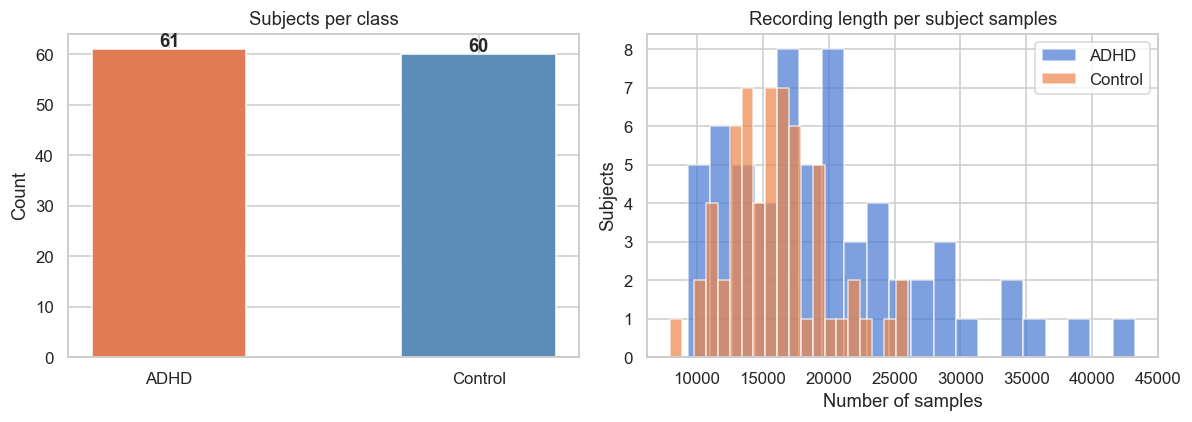

         count     mean     std     min      25%      50%      75%      max
Class                                                                      
ADHD      61.0  19788.0  7442.0  9286.0  14304.0  18389.0  23681.0  43252.0
Control   60.0  15989.0  3828.0  7983.0  13390.0  15629.0  17805.0  25985.0


In [3]:
subject_info = df.groupby('ID').agg(
    label=('label', 'first'),
    n_samples=('label', 'count')
).reset_index()
subject_info['Class'] = subject_info['label'].map({1: 'ADHD', 0: 'Control'})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = subject_info['Class'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e07b54', '#5b8db8'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Subjects per class')
axes[0].set_ylabel('Count')

for cls, grp in subject_info.groupby('Class'):
    axes[1].hist(grp['n_samples'], bins=20, alpha=0.7, label=cls)
axes[1].set_title('Recording length per subject samples')
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Subjects')
axes[1].legend()

plt.tight_layout()
plt.show()

print(subject_info.groupby('Class')['n_samples'].describe().round(0))

Missing values and basic signal quality

In [4]:
missing = df[EEG_CHANNELS].isnull().sum()
print("missing values per channel:")
print(missing[missing > 0] if missing.any() else "none.")

desc = df[EEG_CHANNELS].describe().T[['mean', 'std', 'min', 'max']]
print(f"\nglobal amplitude range: [{desc['min'].min():.2f}, {desc['max'].max():.2f}]")
print(f"mean std across channels: {desc['std'].mean():.4f}")
desc

missing values per channel:
none.

global amplitude range: [-13237.00, 13813.00]
mean std across channels: 228.3302


,mean,std,min,max
Fp1,136.090300,275.549744,-3786.0,13813.0
Fp2,136.161874,275.513564,-13224.0,4802.0
F3,142.211730,220.650336,-3921.0,5020.0
F4,136.102201,213.387265,-13237.0,4802.0
F7,142.059967,243.208694,-3995.0,5020.0
F8,141.563308,226.518631,-3958.0,5020.0
C3,142.273664,223.485244,-3921.0,5430.0
C4,142.200533,210.719453,-3921.0,5020.0
Cz,135.183036,213.029495,-3751.0,4802.0
T7,141.745176,227.233709,-3958.0,5020.0


Signal amplitude distribution

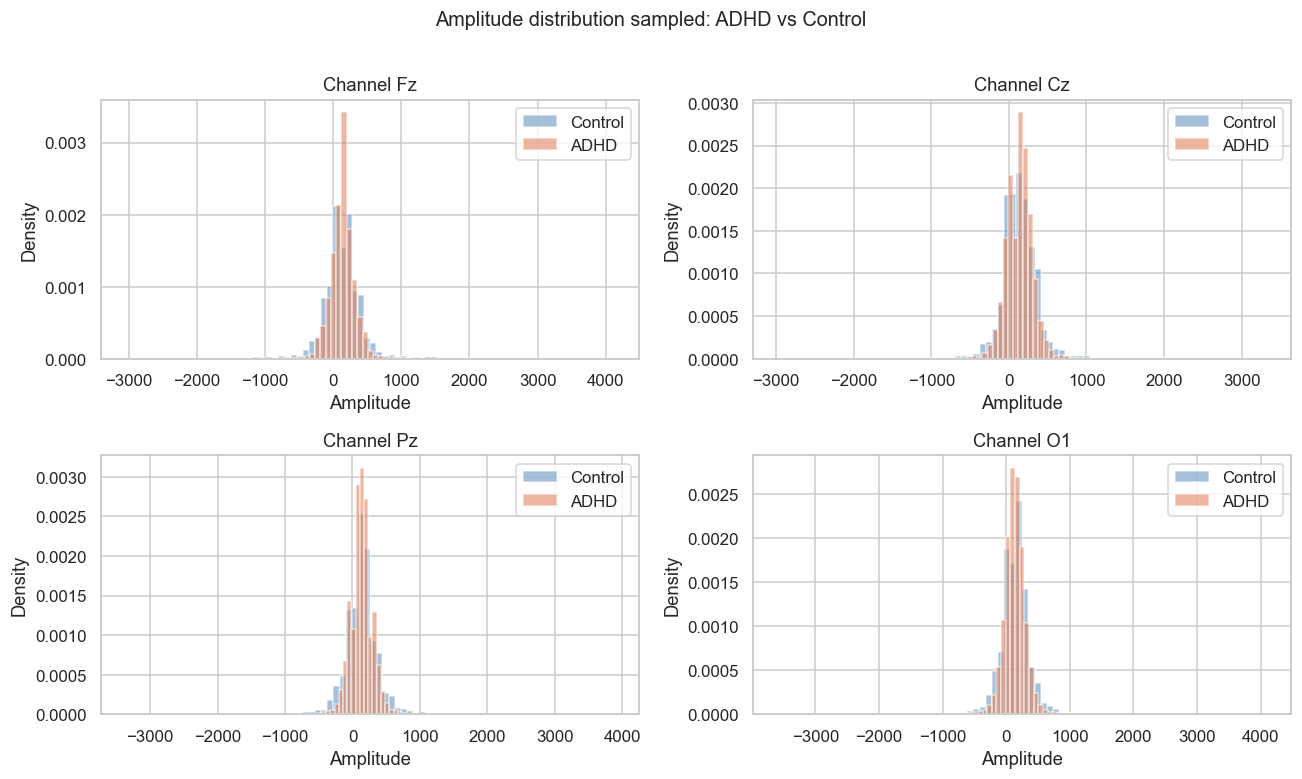

In [5]:
sample = df.sample(n=min(50000, len(df)), random_state=42)

channels_plot = ['Fz', 'Cz', 'Pz', 'O1']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, ch in zip(axes, channels_plot):
    for label, color, name in [(0, '#5b8db8', 'Control'), (1, '#e07b54', 'ADHD')]:
        vals = sample[sample['label'] == label][ch]
        ax.hist(vals, bins=80, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Amplitude distribution sampled: ADHD vs Control', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Per-channel mean amplitude — ADHD vs Control

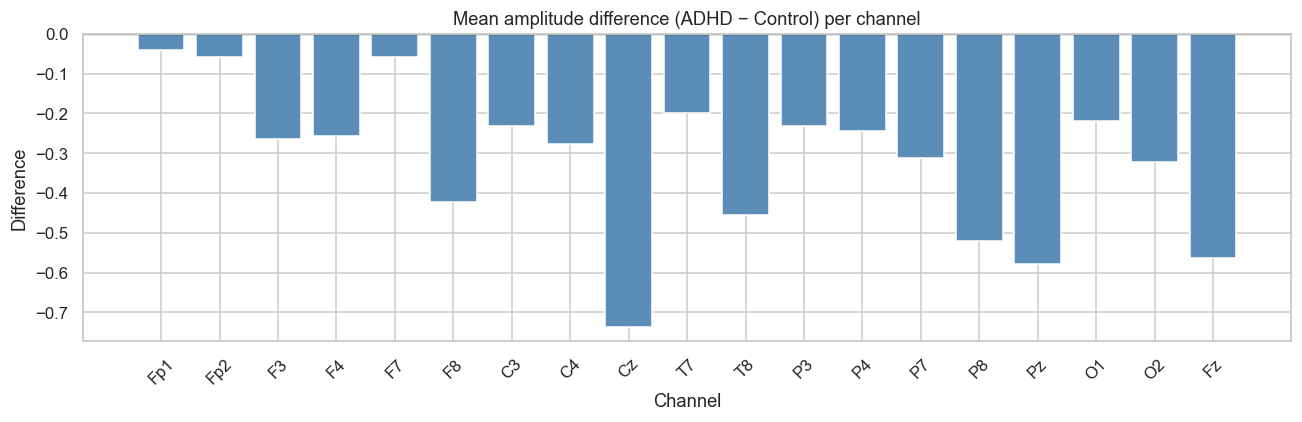

In [6]:
subj_means = df.groupby(['ID', 'label'])[EEG_CHANNELS].mean().reset_index()

ch_stats = subj_means.groupby('label')[EEG_CHANNELS].mean().T
ch_stats.columns = ['Control', 'ADHD']
ch_stats['diff'] = ch_stats['ADHD'] - ch_stats['Control']

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e07b54' if v > 0 else '#5b8db8' for v in ch_stats['diff']]
ax.bar(ch_stats.index, ch_stats['diff'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Mean amplitude difference (ADHD − Control) per channel')
ax.set_xlabel('Channel')
ax.set_ylabel('Difference')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Frequency band power: ADHD vs Control

In [ ]:
FREQ_BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0),
}

def subject_band_powers(group):
    signal = group[EEG_CHANNELS].values
    n = signal.shape[0]
    nperseg = min(n, SAMPLING_FREQ * 4)
    row = {}
    for band, (lo, hi) in FREQ_BANDS.items():
        powers = []
        for ch_idx in range(signal.shape[1]):
            freqs, psd = welch(signal[:, ch_idx], fs=SAMPLING_FREQ, nperseg=nperseg)
            mask = (freqs >= lo) & (freqs < hi)
            powers.append(np.trapezoid(psd[mask], freqs[mask]))
        row[band] = np.mean(powers)
    return pd.Series(row)

print("computing band powers...")
band_df = df.groupby(['ID', 'label']).apply(subject_band_powers, include_groups=False).reset_index()
band_df['Class'] = band_df['label'].map({1: 'ADHD', 0: 'Control'})
print("done")
band_df.head(3)


computing band powers per subject...
done


,ID,label,delta,theta,alpha,beta,Class
0,v107,0,80244.767259,9094.989489,2860.664127,2088.210152,Control
1,v108,0,39421.061075,2628.581998,1475.305560,740.622615,Control
2,v109,0,237118.694484,10382.359297,4327.501592,5110.870382,Control


C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\441298299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\441298299.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\441298299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\441298299.py:7: FutureWarning: 

Passin

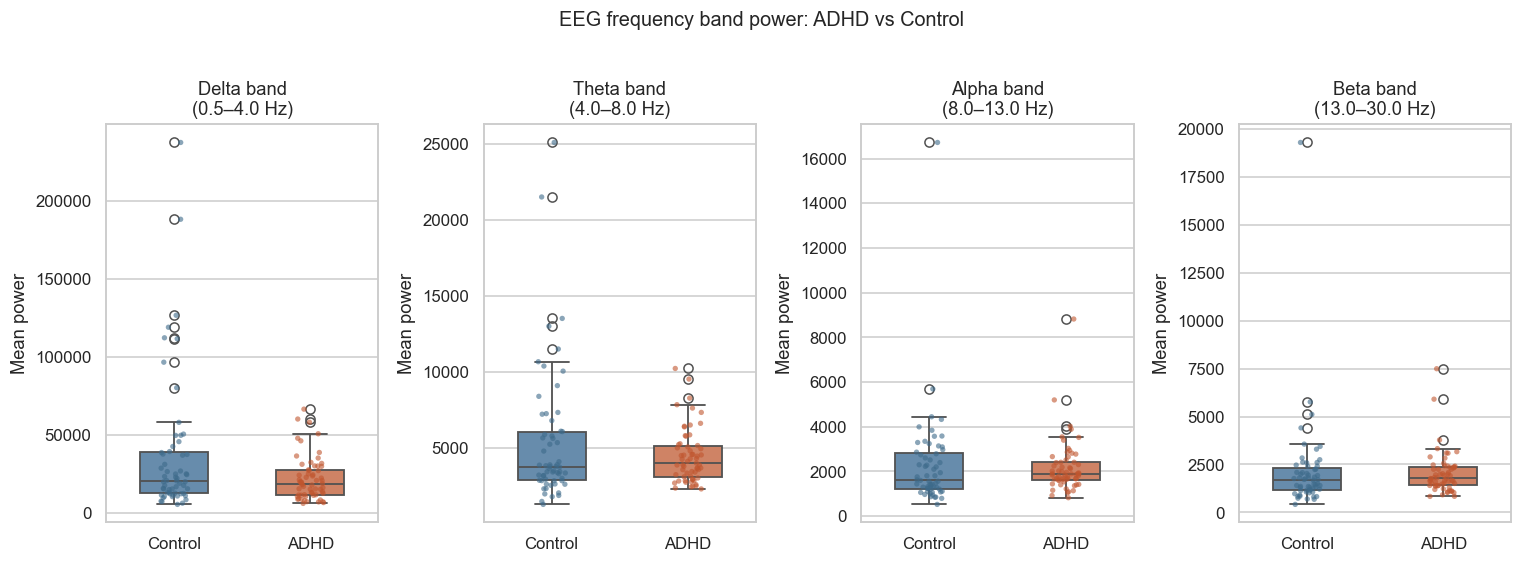

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, band in zip(axes, FREQ_BANDS):
    sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
                palette={'ADHD': '#e07b54', 'Control': '#5b8db8'},
                width=0.5, linewidth=1.2)
    sns.stripplot(data=band_df, x='Class', y=band, ax=ax,
                  palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
                  size=3.5, alpha=0.6, jitter=True)
    ax.set_title(f'{band.capitalize()} band\n({FREQ_BANDS[band][0]}–{FREQ_BANDS[band][1]} Hz)')
    ax.set_xlabel('')
    ax.set_ylabel('Mean power')

plt.suptitle('EEG frequency band power: ADHD vs Control', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Theta/Alpha ratio (TAR)

C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\2224585140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\2224585140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,


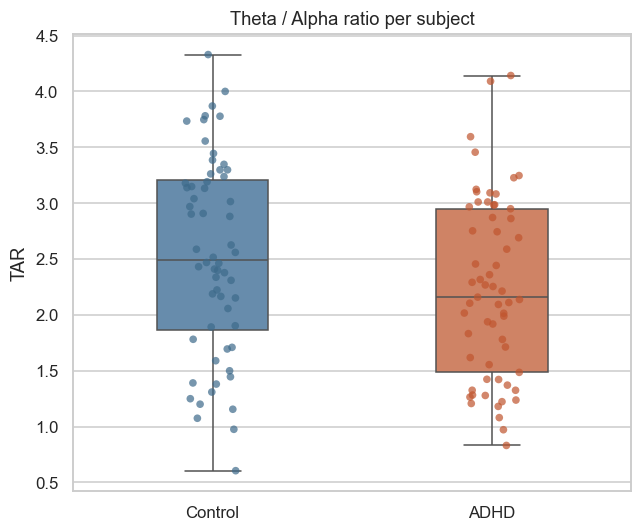

         count    mean     std     min     25%     50%     75%     max
Class                                                                 
ADHD      61.0  2.2308  0.8022  0.8315  1.4857  2.1589  2.9502  4.1428
Control   60.0  2.5286  0.8850  0.6056  1.8644  2.4926  3.2035  4.3302


In [9]:
band_df['theta_alpha_ratio'] = band_df['theta'] / (band_df['alpha'] + 1e-12)

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
            palette={'ADHD': '#e07b54', 'Control': '#5b8db8'}, width=0.4)
sns.stripplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
              palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
              size=5, alpha=0.7, jitter=True)
ax.set_title('Theta / Alpha ratio per subject')
ax.set_ylabel('TAR')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(band_df.groupby('Class')['theta_alpha_ratio'].describe().round(4))

Channel correlation heatmap

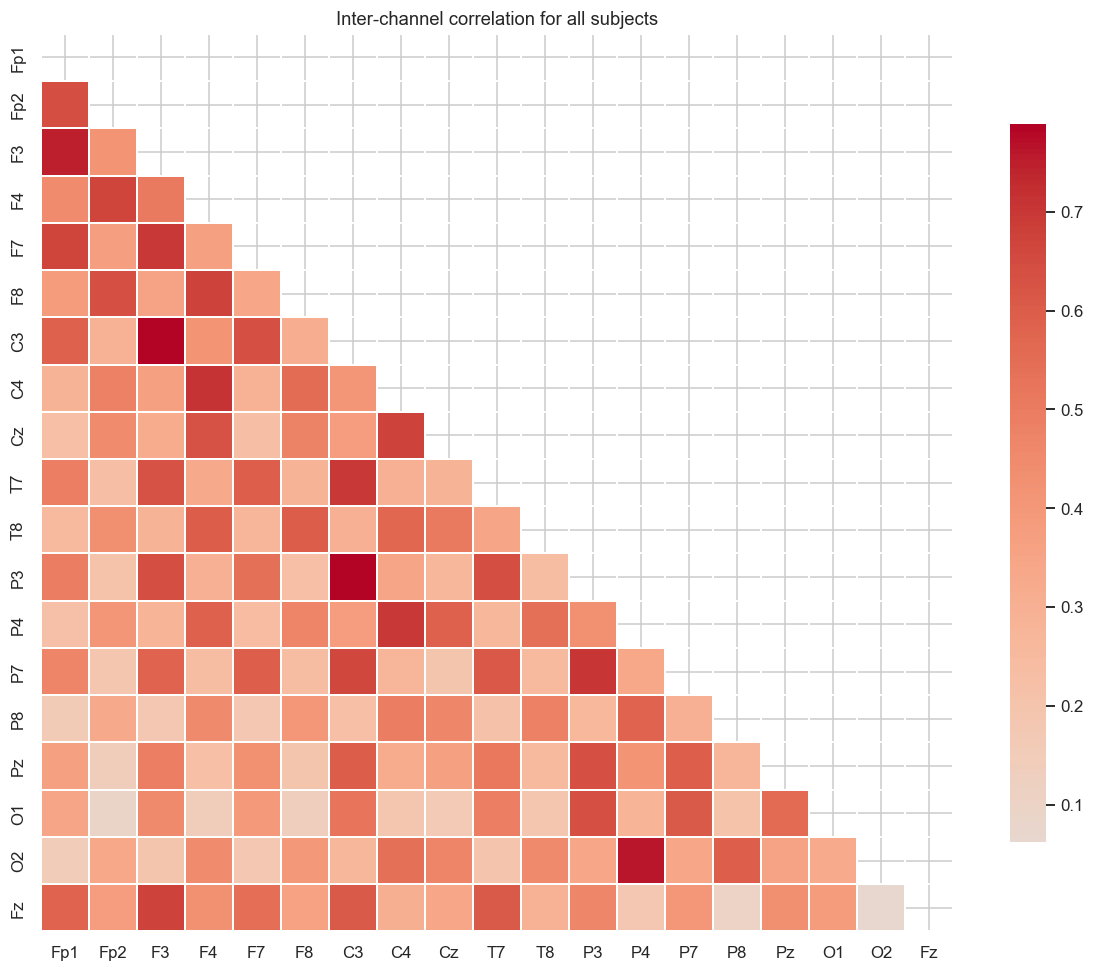

In [10]:
sample_corr = df.sample(n=min(30000, len(df)), random_state=0)
corr = sample_corr[EEG_CHANNELS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Inter-channel correlation for all subjects')
plt.tight_layout()
plt.show()

Subject-level variance

C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\1060626412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_std, x='Class', y='mean_std',
C:\Users\kamil\AppData\Local\Temp\ipykernel_17652\1060626412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=subj_std, x='Class', y='mean_std',


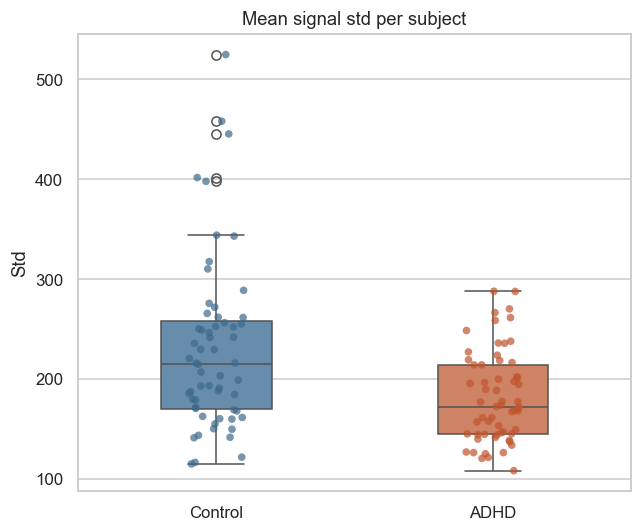

In [11]:
subj_std = df.groupby(['ID', 'label'])[EEG_CHANNELS].std().mean(axis=1).reset_index()
subj_std.columns = ['ID', 'label', 'mean_std']
subj_std['Class'] = subj_std['label'].map({1: 'ADHD', 0: 'Control'})

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=subj_std, x='Class', y='mean_std',
            palette={'ADHD': '#e07b54', 'Control': '#5b8db8'},
            width=0.4, ax=ax)
sns.stripplot(data=subj_std, x='Class', y='mean_std',
              palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
              size=5, alpha=0.7, jitter=True, ax=ax)
ax.set_title('Mean signal std per subject')
ax.set_ylabel('Std')
ax.set_xlabel('')
plt.tight_layout()
plt.show()